# Projekt 1 - Planetary Grand Tour

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
#til animationer
from matplotlib import animation, rc
from IPython.display import HTML
rc('animation', html='jshtml')

In [2]:
#Tabeller i SI enheder

#planeter
N = ["Solen", "Jorden", "Mars", "Jupiter", "Saturn", "Uranus", "Neptun", "Pluto"]
#Masser i kg (*10**24)
M = np.array([1988550, 5.97 ,0.642, 1898, 568, 86.8, 102, 0.013])*10**24
#Diameter m
d = np.array([1391684, 12756, 6792, 142984, 120536, 1118, 49528, 23909])*1000
#Omløbstid i sek
T = np.array([1e-12, 365.2, 687.0, 4331, 10747, 30589, 59800, 90588])*24*60*60
#Baneradius m
r = np.array([0, 149.6, 227.9, 778.6, 1433.5, 2872.5, 4495.1, 5870])*1000*10**6
#Fase i radianer
ø = np.array([0, 0, 76.5, 113, 173, -106, -72.1, -134])*np.pi/180

#Gravitattionskonstanten m**3/kg*s**2
G = 6.67384*10**(-11)
#Voyager kg
m_voy = 722

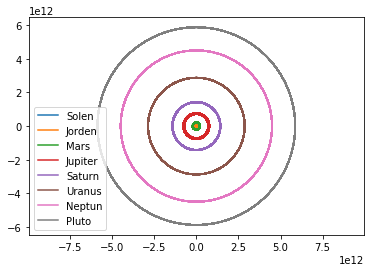

In [3]:
#Planetbaner i Loop
a=[0,1,2,3,4,5,6,7]# argumenter til i
t = np.linspace(0, 500000000000, 10000)
    
for i in a:
    def planet_movementx(t):
        return r[i]*np.cos((2*np.pi)/T[i]*t+ø[i])
    def planet_movementy(t):
        return r[i]*np.sin((2*np.pi)/T[i]*t+ø[i])
    plt.plot(planet_movementx(t), planet_movementy(t),linestyle="-", ms="1.5", label=N[i])
    plt.axis('equal')
    plt.legend()

## a) - animation

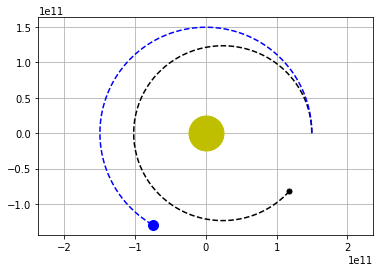

In [4]:
Msol=M[0]
R_jord = d[1]/2

rx0_jord= r[1]*np.cos((2*np.pi)/(T[1])*0+ø[1])
ry0_jord= r[1]*np.sin((2*np.pi)/(T[1])*0+ø[1])

t_span = [0, 2/3*365.2*24*60*60] 
t = np.linspace(0, 2/3*365.2*24*60*60, 100)

#vektorkoordinater for voyager
rx0_voy = rx0_jord+(1.2*R_jord)
ry0_voy = 0
vx0_voy = 0.9*(-r[1]*np.sin((2*np.pi)/T[1]*0+ø[1])*(2*np.pi)/T[1])
vy0_voy = 0.9*(r[1]*np.cos((2*np.pi)/T[1]*0+ø[1])*(2*np.pi)/T[1])

#vektor
y0_voy = [rx0_voy, ry0_voy, vx0_voy, vy0_voy]

#voyagers bane - differentialligning
def voy(t,y):
    rx_voy = y[0]
    ry_voy = y[1]
    vx_voy = y[2]
    vy_voy = y[3]
    drxdt_voy=vx_voy
    drydt_voy=vy_voy
    
    d=np.sqrt(rx_voy**2+ry_voy**2)
    
    dvxdt_voy = -(G*Msol)/(abs(d**3))*rx_voy
    dvydt_voy = -(G*Msol)/(abs(d**3))*ry_voy
                           
    return [drxdt_voy, drydt_voy, dvxdt_voy, dvydt_voy]

#løsning af differentialligning
res_voy = solve_ivp(voy, t_span, y0_voy, t_eval = t, rtol = 10**-9)

#figur
fig, ax = plt.subplots(1,1)
ax.plot(0, 0, 'yo', ms="35")#solen
ax.axis("equal")
ax.grid()

#voyagers bevægelser
voyager_line, = ax.plot(res_voy.y[0], res_voy.y[1], color="black",linestyle="--", label="Voyager bane")#banebevægelsen
voyager, = ax.plot(res_voy.y[0][0], res_voy.y[1][0], color="black", marker="o", ls="", ms=5, label="Voyager")


#Jordens vektor koordinater fra udgangspunktet.
rx0_jord = (r[1])*np.cos((2*np.pi)/T[1]*0+ø[1])
ry0_jord = 0
vx0_jord = -r[1]*np.sin((2*np.pi)/T[1]*0+ø[1])*(2*np.pi)/T[1]
vy0_jord = r[1]*np.cos((2*np.pi)/T[1]*0+ø[1])*(2*np.pi)/T[1]

#vektor
y0_jord = [rx0_jord, ry0_jord, vx0_jord, vy0_jord]

#Jordens bane - differentialligning
def jord(t,y):
    rx_jord = r[1]*np.cos((2*np.pi)/T[1]*t+ø[1])
    ry_jord = r[1]*np.sin((2*np.pi)/T[1]*t+ø[1])
    vx_jord = -r[1]*np.sin((2*np.pi)/T[1]*t+ø[1])*(2*np.pi)/T[1]
    vy_jord = r[1]*np.cos((2*np.pi)/T[1]*t+ø[1])*(2*np.pi)/T[1]
    return [vx_jord, vy_jord, rx_jord, ry_jord]

#løsning af differentialligning
res_jord = solve_ivp(jord, t_span, y0_jord, t_eval = t, rtol = 10**-9)

#Jordens bevægelse
jorden_line, = ax.plot(res_jord.y[0], res_jord.y[1], linestyle="--", label="Jordens bane", color="blue")#banebevægelsen
jorden, = ax.plot(res_jord.y[0][0], res_jord.y[1][0], marker="o", ms="10", label="Jorden", color="blue")


#animation
def update(i):
       
    voyager_line.set_data(res_voy.y[0][0:i+1], res_voy.y[1][0:i+1])
    voyager.set_data(res_voy.y[0][i], res_voy.y[1][i])
    jorden_line.set_data(res_jord.y[0][0:i+1], res_jord.y[1][0:i+1])
    jorden.set_data(res_jord.y[0][i], res_jord.y[1][i])
    
    return voyager_line, voyager, jorden_line, jorden


anim = animation.FuncAnimation(fig, 
                               update,
                               frames = 100,
                               interval=10,
                               blit=True)
anim

# b)

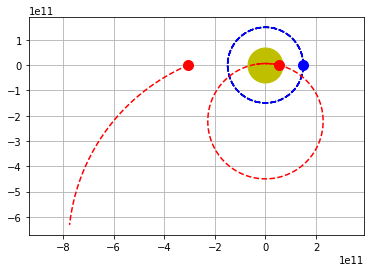

In [9]:
Msol=M[0]
M_jord = M[1]
R_jord = d[1]/2

rx0_jord= r[1]*np.cos((2*np.pi)/(T[1])*0+ø[1])
ry0_jord= r[1]*np.sin((2*np.pi)/(T[1])*0+ø[1])

t_span = [0, 2*365.2*24*60*60] 
t = np.linspace(0, 2*365.2*24*60*60, 100)

#vektorkoordinater for voyager
rx0_voy = rx0_jord+(1.2*R_jord)
ry0_voy = 0
vx0_voy = 0.9*(-r[1]*np.sin((2*np.pi)/T[1]*0+ø[1])*(2*np.pi)/T[1])
vy0_voy = 0.9*(r[1]*np.cos((2*np.pi)/T[1]*0+ø[1])*(2*np.pi)/T[1])

#vektor
y0_voy = [rx0_voy, ry0_voy, vx0_voy, vy0_voy]

#voyagers bane - differentialligning
def voy(t,y):
    rx_voy = y[0]
    ry_voy = y[1]
    vx_voy = y[2]
    vy_voy = y[3]
    drxdt_voy = vx_voy
    drydt_voy = vy_voy
    rx_jord = r[1]*np.cos(2*np.pi/T[1]*t+ø[1])
    ry_jord = r[1]*np.sin(2*np.pi/T[1]*t+ø[1])
    
    d=np.sqrt(rx_voy**2+ry_voy**2)
    d_jord=np.sqrt((rx_voy-rx_jord)**2+(ry_voy-ry_jord)**2)
    
    
    dvxdt_voy = -(Msol*G)/(abs(d**3))*rx_voy+(-M_jord*G)/(abs(d_jord**3))*(rx_voy-rx_jord)
    dvydt_voy = -(Msol*G)/(abs(d**3))*ry_voy+(-M_jord*G)/(abs(d_jord**3))*(ry_voy-ry_jord)
                           
    return [drxdt_voy, drydt_voy, dvxdt_voy, dvydt_voy]

#løsning af differentialligning
res_voy = solve_ivp(voy, t_span, y0_voy, t_eval = t, rtol = 10**-9)

#figur
fig, ax = plt.subplots(1,1)
ax.plot(0, 0, 'yo', ms="35")#solen
ax.axis("equal")
ax.grid()

#voyagers bevægelser
voyager_line, = ax.plot(res_voy.y[0], res_voy.y[1], color="black",linestyle="--", label="Voyager bane")#banebevægelsen
voyager, = ax.plot(res_voy.y[0][0], res_voy.y[1][0], color="black", marker="o", ls="", ms=5, label="Voyager")


#Jordens vektor koordinater fra udgangspunktet.
rx0_jord = (r[1])*np.cos((2*np.pi)/T[1]*0+ø[1])
ry0_jord = 0
vx0_jord = -r[1]*np.sin((2*np.pi)/T[1]*0+ø[1])*(2*np.pi)/T[1]
vy0_jord = r[1]*np.cos((2*np.pi)/T[1]*0+ø[1])*(2*np.pi)/T[1]

#vektor
y0_jord = [rx0_jord, ry0_jord, vx0_jord, vy0_jord]

#Jordens bane - differentialligning
def jord(t,y):
    rx_jord = r[1]*np.cos((2*np.pi)/T[1]*t+ø[1])
    ry_jord = r[1]*np.sin((2*np.pi)/T[1]*t+ø[1])
    vx_jord = -r[1]*np.sin((2*np.pi)/T[1]*t+ø[1])*(2*np.pi)/T[1]
    vy_jord = r[1]*np.cos((2*np.pi)/T[1]*t+ø[1])*(2*np.pi)/T[1]
    return [vx_jord, vy_jord, rx_jord, ry_jord]

#løsning af differentialligning
res_jord = solve_ivp(jord, t_span, y0_jord, t_eval = t, rtol = 10**-9)

#Jordens bevægelse
jorden_line, = ax.plot(res_jord.y[0], res_jord.y[1], linestyle="--", label="Jordens bane", color="blue")#banebevægelsen
jorden, = ax.plot(res_jord.y[0][0], res_jord.y[1][0], marker="o", ms="10", label="Jorden", color="blue")




#Mars vektor koordinater fra udgangspunktet.
rx0_mars = (r[2])*np.cos((2*np.pi)/T[2]*0+ø[2])
ry0_mars = 0
vx0_mars = -r[2]*np.sin((2*np.pi)/T[2]*0+ø[2])*(2*np.pi)/T[2]
vy0_mars = r[2]*np.cos((2*np.pi)/T[2]*0+ø[2])*(2*np.pi)/T[2]

#vektor
y0_mars = [rx0_mars, ry0_mars, vx0_mars, vy0_mars]

#Mars bane - differentialligning
def mars(t,y):
    rx_mars = r[2]*np.cos((2*np.pi)/T[2]*t+ø[2])
    ry_mars = r[2]*np.sin((2*np.pi)/T[2]*t+ø[2])
    vx_mars = -r[2]*np.sin((2*np.pi)/T[2]*t+ø[2])*(2*np.pi)/T[2]
    vy_mars = r[2]*np.cos((2*np.pi)/T[2]*t+ø[2])*(2*np.pi)/T[2]
    return [vx_mars, vy_mars, rx_mars, ry_mars]

#løsning af differentialligning
res_mars = solve_ivp(mars, t_span, y0_mars, t_eval = t, rtol = 10**-9)

#Mars bevægelse
mars_line, = ax.plot(res_mars.y[0], res_mars.y[1], linestyle="--", label="Mars bane", color="red")#banebevægelsen
mars, = ax.plot(res_mars.y[0][0], res_mars.y[1][0], marker="o", ms="10", label="Mars", color="red")



#Jupiter vektor koordinater fra udgangspunktet.
rx0_jupiter = (r[3])*np.cos((2*np.pi)/T[3]*0+ø[3])
ry0_jupiter = 0
vx0_jupiter = -r[3]*np.sin((2*np.pi)/T[3]*0+ø[3])*(2*np.pi)/T[3]
vy0_jupiter = r[3]*np.cos((2*np.pi)/T[3]*0+ø[3])*(2*np.pi)/T[3]

#vektor
y0_jupiter = [rx0_jupiter, ry0_jupiter, vx0_jupiter, vy0_jupiter]

#Jupiter bane - differentialligning
def jupiter(t,y):
    rx_jupiter = r[3]*np.cos((2*np.pi)/T[3]*t+ø[3])
    ry_jupiter = r[3]*np.sin((2*np.pi)/T[3]*t+ø[3])
    vx_jupiter = -r[3]*np.sin((2*np.pi)/T[3]*t+ø[3])*(2*np.pi)/T[3]
    vy_jupiter = r[3]*np.cos((2*np.pi)/T[3]*t+ø[3])*(2*np.pi)/T[3]
    return [vx_jupiter, vy_jupiter, rx_jupiter, ry_jupiter]

#løsning af differentialligning
res_jupiter = solve_ivp(jupiter, t_span, y0_jupiter, t_eval = t, rtol = 10**-9)

#Jupiters bevægelse
jupiter_line, = ax.plot(res_jupiter.y[0], res_jupiter.y[1], linestyle="--", label="Jupiter bane", color="red")#banebevægelsen
jupiter, = ax.plot(res_jupiter.y[0][0], res_jupiter.y[1][0], marker="o", ms="10", label="Jupiter", color="red")



#animation
#def update(i):
       
#    voyager_line.set_data(res_voy.y[0][0:i+1], res_voy.y[1][0:i+1])
 #   voyager.set_data(res_voy.y[0][i], res_voy.y[1][i])
  #  jorden_line.set_data(res_jord.y[0][0:i+1], res_jord.y[1][0:i+1])
   # jorden.set_data(res_jord.y[0][i], res_jord.y[1][i])
    #mars_line.set_data(res_mars.y[0][0:i+1], res_mars.y[1][0:i+1])
    #mars.set_data(res_mars.y[0][i], res_mars.y[1][i])
    #jupiter_line.set_data(res_jupiter.y[0][0:i+1], res_jupiter.y[1][0:i+1])
    #jupiter.set_data(res_jupiter.y[0][i], res_jupiter.y[1][i])
    
    #return voyager_line, voyager, jorden_line, jorden, mars_line, mars, jupiter_line, jupiter


#anim = animation.FuncAnimation(fig, 
#                               update,
#                               frames = 100,
#                               interval=10,
#                               blit=True)
#anim